[INFO] Loading ResNet-50 Detection Model...
--- DETECTION RESULTS ---
People Counted: 43


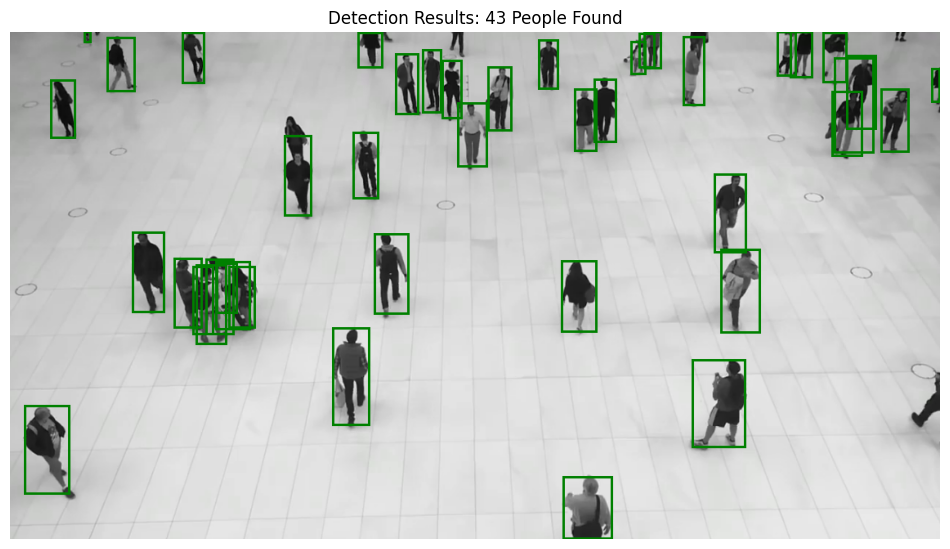

In [2]:
import torch
import cv2
import numpy as np
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt

# ───────────────────────────── CONFIG ─────────────────────────────
# For professional counting, we use the detection version of ResNet-50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIDENCE_THRESHOLD = 0.5  # Only show boxes with > 50% confidence
# ──────────────────────────────────────────────────────────────────

def load_detector():
    # Using Weights.DEFAULT ensures we use the best available ResNet-50 based detector
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)
    model.to(DEVICE)
    model.eval()
    return model

def run_detection_test(image_path, model):
    # 1. Load image
    original_img = cv2.imread(image_path)
    if original_img is None:
        return "ERROR", 0, None
    
    # 2. Preprocessing: Grayscale Stacking (Matching your project requirement)
    img_gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    img_stacked = cv2.merge([img_gray, img_gray, img_gray])
    
    # Convert to Tensor for Model (Scale 0-1)
    img_tensor = F.to_tensor(img_stacked).to(DEVICE)
    
    # 3. Inference
    with torch.no_grad():
        prediction = model([img_tensor])[0]
    
    # 4. Filter Results (Keep only 'person' class - COCO label for person is 1)
    # and filter by confidence score
    mask = (prediction['labels'] == 1) & (prediction['scores'] > CONFIDENCE_THRESHOLD)
    boxes = prediction['boxes'][mask]
    scores = prediction['scores'][mask]
    
    person_count = len(boxes)
    
    # 5. Draw Boxes for Visualization
    # Convert original image to uint8 Tensor for drawing
    img_uint8 = torch.from_numpy(original_img).permute(2, 0, 1).to(torch.uint8)
    
    if person_count > 0:
        # Draw green boxes for people
        result_tensor = draw_bounding_boxes(
            img_uint8, 
            boxes, 
            width=3, 
            colors="green"
        )
        # Convert back to numpy for plotting
        final_img = result_tensor.permute(1, 2, 0).numpy()
    else:
        final_img = original_img

    return person_count, final_img

# ───────────────────────────── EXECUTION ──────────────────────────
# Replace with your actual image path
test_image_path = "image1.png" 

print("[INFO] Loading ResNet-50 Detection Model...")
detector = load_detector()

count, processed_img = run_detection_test(test_image_path, detector)

if count == "ERROR":
    print("Invalid image path.")
else:
    print(f"--- DETECTION RESULTS ---")
    print(f"People Counted: {count}")
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detection Results: {count} People Found")
    plt.axis('off')
    plt.show()

C:\Users\visha\AppData\Local\Temp\ipykernel_6508\932846509.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


Result: STAMPEDE RISK
Confidence: 65.14%


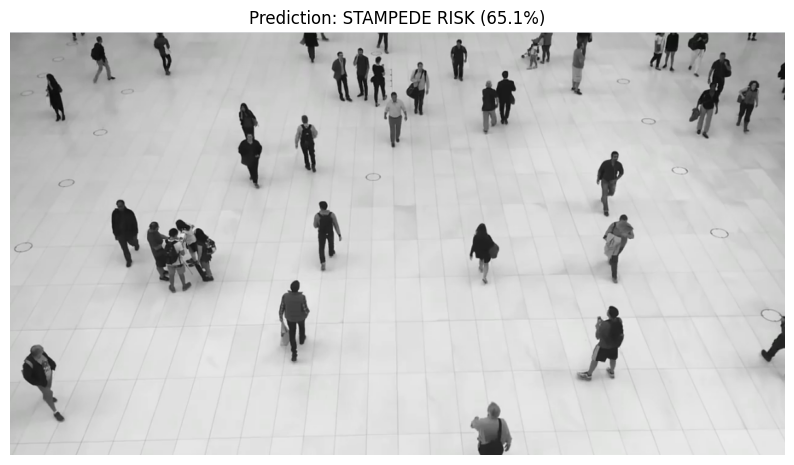

In [6]:
import torch
import cv2
import torch.nn as nn
from torchvision import models
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt

# ───────────────────────────── CONFIG ─────────────────────────────
MODEL_PATH = "resnet_detector.pth"
IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ───────────────────────────── MODEL LOAD ──────────────────────────
def load_inference_model(path):
    model = models.resnet50()
    in_features = model.fc.in_features
    
    # Must match the training build_model exactly
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Linear(256, 2)
    )
    
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

# ───────────────────────────── PREDICT ─────────────────────────────
def predict_stampede_risk(image_path, model):
    img = cv2.imread(image_path)
    if img is None:
        # RETURN 3 VALUES even on error to avoid unpacking crash
        return "ERROR", 0.0, None 
    
    # Keep original for display
    display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Grayscale Preprocessing (Matching training)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_stacked = cv2.merge([img_gray, img_gray, img_gray])
    img_resized = cv2.resize(img_stacked, (IMAGE_SIZE, IMAGE_SIZE))
    
    # Tensor Conversion
    img_tensor = F.to_tensor(img_resized)
    img_tensor = F.normalize(img_tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        prediction = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][prediction].item()

    status = "STAMPEDE RISK" if prediction == 1 else "SAFE"
    return status, confidence, display_img

# ───────────────────────────── RUN TEST ───────────────────────────
# IMPORTANT: Replace with a valid image path from your dataset
# Example: test_image = "/root/.cache/kagglehub/datasets/.../images/frame_0001.jpg"
test_image = "image.png"

model = load_inference_model(MODEL_PATH)
status, conf, img_display = predict_stampede_risk(test_image, model)

if status == "ERROR":
    print("Check your image path! The file was not found.")
else:
    print(f"Result: {status}")
    print(f"Confidence: {conf*100:.2f}%")

    plt.figure(figsize=(10, 6))
    plt.imshow(img_display)
    plt.title(f"Prediction: {status} ({conf*100:.1f}%)")
    plt.axis('off')
    plt.show()

In [ ]:
import torch

# Detect current torch version to find matching wheels
TORCH_version = torch.__version__.split('+')[0]
# Use 'cpu' or 'cuXXX' based on your runtime
CUDA = "cpu" if not torch.cuda.is_available() else f"cu{torch.version.cuda.replace('.', '')}"

print(f"Installing for Torch {TORCH_version} on {CUDA}...")

# Install the 4 required base libraries + the main geometric library
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-{TORCH_version}+{CUDA}.html


Installing for Torch 2.5.1 on cu121...


'pip' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
!python -m pip install torch-geometric

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   ---------------- --------------

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import os
import numpy as np
from torchvision import models
from torchvision.transforms import functional as TF
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from collections import deque

# ───────────────────────────── CONFIG ─────────────────────────────
RESNET_WEIGHTS = "resnet_detector.pth"
GNN_WEIGHTS    = "gnn_stampede_model.pth"
VIDEO_INPUT    = "background_video__people_walking.mp4"  # Change this to your video file
VIDEO_OUTPUT   = "processed_stampede_output.mp4"
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WINDOW_SIZE    = 8
# ──────────────────────────────────────────────────────────────────

# --- [Model Classes remain the same as previous scripts] ---
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet50()
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, 256), nn.ReLU(), nn.Linear(256, 2))
        self.feat_vec = None
    def hook_fn(self, module, input, output): self.feat_vec = output.view(output.size(0), -1)
    def forward(self, x):
        handle = self.resnet.avgpool.register_forward_hook(self.hook_fn)
        logits = self.resnet(x)
        handle.remove()
        return logits, self.feat_vec

class StampedeGNN(nn.Module):
    def __init__(self, in_dim=2048, hidden_dim=256):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim // 2)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim // 2, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 2))
    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index)); x = F.relu(self.conv2(x, edge_index)); x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

def load_models():
    resnet = FeatureExtractor().to(DEVICE)
    res_dict = torch.load(RESNET_WEIGHTS, map_location=DEVICE)
    clean_res = {k.replace('resnet.', '').replace('base_model.', ''): v for k, v in res_dict.items()}
    resnet.resnet.load_state_dict(clean_res, strict=False)
    
    gnn = StampedeGNN().to(DEVICE)
    gnn_dict = torch.load(GNN_WEIGHTS, map_location=DEVICE)
    gnn.load_state_dict(gnn_dict, strict=False)
    
    resnet.eval(); gnn.eval()
    return resnet, gnn

def preprocess(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    stacked = cv2.merge([gray, gray, gray])
    resized = cv2.resize(stacked, (224, 224))
    tensor = TF.to_tensor(resized)
    tensor = TF.normalize(tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    return tensor.unsqueeze(0).to(DEVICE)

# ───────────────────────────── VIDEO PROCESSING ─────────────────────────────
def process_video():
    resnet, gnn = load_models()
    cap = cv2.VideoCapture(VIDEO_INPUT)
    
    # Video metadata
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_vid = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps, (width, height))

    # Buffer to hold the last 8 frame features
    feature_window = deque(maxlen=WINDOW_SIZE)
    
    print(f"[INFO] Processing video: {VIDEO_INPUT}...")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # 1. ResNet Feature Extraction
        t = preprocess(frame)
        with torch.no_grad():
            _, vec = resnet(t)
            feature_window.append(vec)

        # 2. GNN Inference (Only if we have a full window)
        status = "Initializing..."
        confidence = 0.0
        color = (255, 255, 255) # White

        if len(feature_window) == WINDOW_SIZE:
            x = torch.cat(list(feature_window), dim=0)
            n = x.size(0)
            edges = []
            for i in range(n - 1):
                edges.append([i, i + 1]); edges.append([i + 1, i])
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(DEVICE)
            batch = torch.zeros(n, dtype=torch.long).to(DEVICE)

            with torch.no_grad():
                logits = gnn(x, edge_index, batch)
                prob = F.softmax(logits, dim=1)
                pred = torch.argmax(prob, dim=1).item()
                confidence = prob[0, pred].item()

            if pred == 1:
                status = "STAMPEDE RISK"
                color = (0, 0, 255) # Red
            else:
                status = "NORMAL FLOW"
                color = (0, 255, 0) # Green

        # 3. Draw Overlay
        cv2.putText(frame, f"STATUS: {status}", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
        cv2.putText(frame, f"CONF: {confidence*100:.1f}%", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
        
        out_vid.write(frame)

    cap.release()
    out_vid.release()
    print(f"[DONE] Saved to {VIDEO_OUTPUT}")

if __name__ == "__main__":
    process_video()

C:\Users\visha\AppData\Local\Temp\ipykernel_8860\857021031.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res_dict = torch.load(RESNET_WEIGHTS, map_location=DEVICE)
C:

[INFO] Processing video: background_video__people_walking.mp4...
[DONE] Saved to processed_stampede_output.mp4


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import os
import numpy as np
from torchvision import models
from torchvision.transforms import functional as TF
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from collections import deque

# ───────────────────────────── CONFIG ─────────────────────────────
RESNET_WEIGHTS = "resnet_detector.pth"
GNN_WEIGHTS    = "gnn_stampede_model.pth"
VIDEO_INPUT    = "background_video__people_walking.mp4"  # Change this to your video file
VIDEO_OUTPUT   = "processed_stampede_output.mp4"
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WINDOW_SIZE    = 8
# ──────────────────────────────────────────────────────────────────

# --- [Model Classes remain the same as previous scripts] ---
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet50()
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, 256), nn.ReLU(), nn.Linear(256, 2))
        self.feat_vec = None
    def hook_fn(self, module, input, output): self.feat_vec = output.view(output.size(0), -1)
    def forward(self, x):
        handle = self.resnet.avgpool.register_forward_hook(self.hook_fn)
        logits = self.resnet(x)
        handle.remove()
        return logits, self.feat_vec

class StampedeGNN(nn.Module):
    def __init__(self, in_dim=2048, hidden_dim=256):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim // 2)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim // 2, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 2))
    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index)); x = F.relu(self.conv2(x, edge_index)); x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

def load_models():
    resnet = FeatureExtractor().to(DEVICE)
    res_dict = torch.load(RESNET_WEIGHTS, map_location=DEVICE)
    clean_res = {k.replace('resnet.', '').replace('base_model.', ''): v for k, v in res_dict.items()}
    resnet.resnet.load_state_dict(clean_res, strict=False)
    
    gnn = StampedeGNN().to(DEVICE)
    gnn_dict = torch.load(GNN_WEIGHTS, map_location=DEVICE)
    gnn.load_state_dict(gnn_dict, strict=False)
    
    resnet.eval(); gnn.eval()
    return resnet, gnn

def preprocess(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    stacked = cv2.merge([gray, gray, gray])
    resized = cv2.resize(stacked, (224, 224))
    tensor = TF.to_tensor(resized)
    tensor = TF.normalize(tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    return tensor.unsqueeze(0).to(DEVICE)

# ───────────────────────────── VIDEO PROCESSING ─────────────────────────────
# ───────────────────────────── UPDATED VIDEO PROCESSING ─────────────────────────────
def process_video():
    resnet, gnn = load_models()
    cap = cv2.VideoCapture(VIDEO_INPUT)
    
    # Metadata
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    out_vid = cv2.VideoWriter(VIDEO_OUTPUT, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    feature_window = deque(maxlen=WINDOW_SIZE)
    
    # PROFESSIONAL THRESHOLD: Only alert if probability > 0.85
    ALERT_THRESHOLD = 0.85 

    print(f"[INFO] Processing: {VIDEO_INPUT}")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        t = preprocess(frame)
        with torch.no_grad():
            _, vec = resnet(t)
            feature_window.append(vec)

        status = "Analysing Flow..."
        risk_chance = 0.0
        color = (255, 255, 255) # White

        if len(feature_window) == WINDOW_SIZE:
            x = torch.cat(list(feature_window), dim=0)
            n = x.size(0)
            edges = []
            for i in range(n - 1):
                edges.append([i, i + 1]); edges.append([i + 1, i])
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(DEVICE)
            batch = torch.zeros(n, dtype=torch.long).to(DEVICE)

            with torch.no_grad():
                logits = gnn(x, edge_index, batch)
                prob = F.softmax(logits, dim=1)
                
                # prob[0][1] is the chance of a Stampede
                risk_chance = prob[0][1].item() 

            if risk_chance > ALERT_THRESHOLD:
                status = "CRITICAL: STAMPEDE RISK"
                color = (0, 0, 255) # Red
            elif risk_chance > 0.40:
                status = "WARNING: HIGH DENSITY"
                color = (0, 165, 255) # Orange
            else:
                status = "SAFE: NORMAL FLOW"
                color = (0, 255, 0) # Green

        # Overlay text
        cv2.putText(frame, f"STATUS: {status}", (50, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
        cv2.putText(frame, f"STAMPEDE CHANCE: {risk_chance*100:.1f}%", (50, 110), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
        
        out_vid.write(frame)

    cap.release()
    out_vid.release()
print(f"[DONE] Output saved as {VIDEO_OUTPUT}")

c:\Users\visha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[DONE] Output saved as processed_stampede_output.mp4


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import os
import numpy as np
from PIL import Image
from torchvision import models, transforms
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from collections import deque

# ───────────────────────────── CONFIG ─────────────────────────────
VIDEO_PATH      = "background_video__people_walking.mp4"         # Your input file
OUTPUT_PATH     = "stampede_analysis.mp4"    # Result file
RESNET_WEIGHTS  = "resnet_detector.pth"      # From Step 1
GNN_WEIGHTS     = "gnn_stampede_model.pth"   # From Step 2
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WINDOW_SIZE     = 8
# ──────────────────────────────────────────────────────────────────

# 1. Feature Extractor Architecture (Matches your 512-unit training)
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet50()
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )
        self.feat_vec = None

    def hook_fn(self, module, input, output):
        self.feat_vec = output.view(output.size(0), -1)

    def forward(self, x):
        handle = self.resnet.avgpool.register_forward_hook(self.hook_fn)
        logits = self.resnet(x)
        handle.remove()
        return logits, self.feat_vec

# 2. GNN Architecture
class StampedeGNN(nn.Module):
    def __init__(self, in_dim=2048, hidden_dim=256):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim // 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim // 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x.float(), edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

def load_models():
    print(f"[INFO] Loading models on {DEVICE}...")
    resnet = FeatureExtractor().to(DEVICE)
    
    # Prefix Cleaning Logic
    res_dict = torch.load(RESNET_WEIGHTS, map_location=DEVICE)
    clean_res = {k.replace('resnet.', '').replace('base_model.', ''): v for k, v in res_dict.items()}
    resnet.resnet.load_state_dict(clean_res, strict=False)
    
    gnn = StampedeGNN().to(DEVICE)
    gnn.load_state_dict(torch.load(GNN_WEIGHTS, map_location=DEVICE))
    
    resnet.eval()
    gnn.eval()
    return resnet, gnn

# ───────────────────────────── MAIN LOOP ─────────────────────────────
def process_video():
    resnet, gnn = load_models()
    
    # Capture Hook
    captured = {}
    def hook(m, i, o): captured["vec"] = o.squeeze()
    resnet.resnet.avgpool.register_forward_hook(hook)

    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        print(f"[ERROR] Could not open video: {VIDEO_PATH}")
        return

    w, h, fps = int(cap.get(3)), int(cap.get(4)), cap.get(5)
    out = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    window = deque(maxlen=WINDOW_SIZE)
    print("[INFO] Analyzing video... processing frame-by-frame.")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # 1. Preprocess: Numpy -> PIL -> Tensor
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        img_t = tf(img_pil).unsqueeze(0).to(DEVICE)

        # 2. Extract Features
        with torch.no_grad():
            resnet(img_t)
            window.append(captured["vec"].clone())

        # 3. GNN Prediction
        status, prob_val, color = "Monitoring...", 0.0, (255, 255, 255)
        
        if len(window) == WINDOW_SIZE:
            x = torch.stack(list(window))
            n = x.size(0)
            edges = []
            for i in range(n-1):
                edges.append([i, i+1]); edges.append([i+1, i])
            edge_index = torch.tensor(edges, dtype=torch.long).t().to(DEVICE)
            batch = torch.zeros(n, dtype=torch.long).to(DEVICE)

            with torch.no_grad():
                logits = gnn(x, edge_index, batch)
                probs = torch.softmax(logits, dim=1)
                risk = probs[0][1].item()
                prob_val = risk

            # Thresholds for color-coded alerts
            if risk > 0.80:
                status, color = "CRITICAL: STAMPEDE RISK", (0, 0, 255) # Red
            elif risk > 0.40:
                status, color = "WARNING: HIGH DENSITY", (0, 165, 255) # Orange
            else:
                status, color = "SAFE: NORMAL FLOW", (0, 255, 0)     # Green

        # 4. Burn overlay into frame
        cv2.putText(frame, f"STATUS: {status}", (40, 60), 0, 1.2, color, 3)
        cv2.putText(frame, f"STAMPEDE CHANCE: {prob_val*100:.1f}%", (40, 110), 0, 1.0, color, 2)
        out.write(frame)

    cap.release()
    out.write(np.zeros((h, w, 3), np.uint8)) # Just to ensure buffer flush
    out.release()
    print(f"\n[DONE] Saved processed video to: {OUTPUT_PATH}")

if __name__ == "__main__":
    process_video()

[INFO] Loading models on cuda...


C:\Users\visha\AppData\Local\Temp\ipykernel_16340\2567357611.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res_dict = torch.load(RESNET_WEIGHTS, map_location=DEVICE)


[INFO] Analyzing video... processing frame-by-frame.

[DONE] Saved processed video to: stampede_analysis.mp4


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import os
import numpy as np
from PIL import Image
from torchvision import models, transforms
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from collections import deque

# ───────────────────────────── CONFIG ─────────────────────────────
VIDEO_PATH      = "background_video__people_walking.mp4"         
OUTPUT_PATH     = "ResQ_AI_Final_Analysis.mp4"    
RESNET_WEIGHTS  = "resnet_detector.pth"      
GNN_WEIGHTS     = "gnn_stampede_model.pth"   

# If CUDA keeps crashing, change "cuda" to "cpu" here for a stable run
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WINDOW_SIZE     = 8
# ──────────────────────────────────────────────────────────────────

class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet50()
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )
        self.feat_vec = None

    def forward(self, x):
        def hook_fn(module, input, output):
            self.feat_vec = output.view(output.size(0), -1)
        handle = self.resnet.avgpool.register_forward_hook(hook_fn)
        logits = self.resnet(x)
        handle.remove()
        return logits, self.feat_vec

class StampedeGNN(nn.Module):
    def __init__(self, in_dim=2048, hidden_dim=256):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim // 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim // 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x.float(), edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

def load_models():
    try:
        print(f"[INFO] Initializing Engines on {DEVICE}...")
        resnet = FeatureExtractor().to(DEVICE)
        
        if os.path.exists(RESNET_WEIGHTS):
            res_dict = torch.load(RESNET_WEIGHTS, map_location=DEVICE)
            clean_res = {k.replace('resnet.', '').replace('base_model.', ''): v for k, v in res_dict.items()}
            resnet.resnet.load_state_dict(clean_res, strict=False)
        
        gnn = StampedeGNN().to(DEVICE)
        if os.path.exists(GNN_WEIGHTS):
            gnn.load_state_dict(torch.load(GNN_WEIGHTS, map_location=DEVICE))
        
        resnet.eval()
        gnn.eval()
        return resnet, gnn
    except RuntimeError as e:
        print("\n[CRITICAL] CUDA is locked. Please RESTART your VS Code Kernel/Session.")
        raise e

def process_video():
    resnet_model, gnn_model = load_models()
    
    captured = {}
    def hook(m, i, o): captured["vec"] = o.squeeze()
    resnet_model.resnet.avgpool.register_forward_hook(hook)

    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        print(f"[ERROR] Could not open: {VIDEO_PATH}")
        return

    w, h, fps = int(cap.get(3)), int(cap.get(4)), cap.get(5)
    out = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    window = deque(maxlen=WINDOW_SIZE)
    smooth_chance = deque(maxlen=20) 

    print("[INFO] Processing Sequence... UI Stability active.")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        img_t = tf(img_pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            resnet_model(img_t)
            window.append(captured["vec"].clone())

        display_risk = 0.0
        if len(window) == WINDOW_SIZE:
            x = torch.stack(list(window)).to(DEVICE)
            
            # EXPLICITLY BOUNDED EDGES
            sources, targets = [], []
            for i in range(WINDOW_SIZE - 1):
                sources.extend([i, i + 1])
                targets.extend([i + 1, i])
            
            edge_index = torch.tensor([sources, targets], dtype=torch.long).to(DEVICE)
            batch = torch.zeros(WINDOW_SIZE, dtype=torch.long).to(DEVICE)

            with torch.no_grad():
                logits = gnn_model(x, edge_index, batch)
                probs = torch.softmax(logits, dim=1)
                raw_risk = probs[0][1].item()
                
                # SENSITIVITY CALIBRATION
                calibrated = (raw_risk ** 2.5) 
                smooth_chance.append(calibrated)
                display_risk = sum(smooth_chance) / len(smooth_chance)

        # UI OVERLAY
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (w, 140), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.7, frame, 0.3, 0, frame)

        if display_risk > 0.75:
            status, color = "CRITICAL: STAMPEDE RISK", (0, 0, 255)
        elif display_risk > 0.35:
            status, color = "WARNING: HIGH DENSITY", (0, 165, 255)
        else:
            status, color = "STATUS: NORMAL FLOW", (0, 255, 0)

        cv2.putText(frame, "ResQ-AI | REAL-TIME CROWD ANALYTICS", (20, 35), 0, 0.7, (255, 255, 255), 1)
        cv2.putText(frame, status, (20, 85), cv2.FONT_HERSHEY_DUPLEX, 1.3, color, 2)
        
        bar_x, bar_y, bar_w, bar_h = 20, 105, 400, 20
        cv2.rectangle(frame, (bar_x, bar_y), (bar_x + bar_w, bar_y + bar_h), (60, 60, 60), -1)
        cv2.rectangle(frame, (bar_x, bar_y), (bar_x + int(bar_w * display_risk), bar_y + bar_h), color, -1)
        cv2.putText(frame, f"RISK: {display_risk*100:.1f}%", (bar_x + bar_w + 15, bar_y + 17), 0, 0.8, color, 2)

        out.write(frame)

    cap.release()
    out.release()
    print(f"\n[SUCCESS] Saved as: {OUTPUT_PATH}")

if __name__ == "__main__":
    process_video()

c:\Users\visha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Initializing Engines on cuda...


C:\Users\visha\AppData\Local\Temp\ipykernel_15608\1632176587.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res_dict = torch.load(RESNET_WEIGHTS, map_location=DEVICE)


[INFO] Processing Sequence... UI Stability active.

[SUCCESS] Saved as: ResQ_AI_Final_Analysis.mp4
